## Challenge Exercise 2 (CE2)

### See Canvas for assignment dates

****

## Collaboration policy

This is a **group assignment**. Each group may have **up to four students**, and there are **no pre-assigned groups**. **All group members must be different from those in CE1**—there may be **no overlap** with any previous group.

Please be **welcoming and considerate** when forming groups. You are encouraged to reach out to classmates you may not know well and to act as a supportive, inclusive member of the class. If you are unsure about what is or is not allowed, **you must ask for clarification in advance**. Claiming confusion or uncertainty after the fact will not be accepted as an excuse.

**Collaboration is permitted only within your assigned team.** There may be **no collaboration, discussion, or sharing of work between different teams**. All submitted work must be **entirely the product of your own team**.

To ensure fairness for everyone, the **collaboration policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.

In the **Markdown cell below**, list the **full names of all members of your group**.


### Team members

1. Yahan Yang
2. put fullname
3. put fullname
4. put fullname

****
## AI policy

AI may not be used to generate a coding solution. Your solution must be your own work. If you have any questions about what is or isn't allowed, you must ask. Saying afterwards that you didn't understand or were unsure is not an acceptable excuse.

To ensure fairness for everyone, the **AI policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.



****
## Honor pledge

To acknowledge and understand the **Collaboration and AI policies** outlined above, each team member must enter their Onyen and PID in this markdown cell.

1. ayahan, 730649168
2. Onyen and PID
3. Onyen and PID
4. Onyen and PID

****

## Python modules

All the Python modules needed to complete this CE are provided to you. 

<span style="background-color: #FFFF00">**No other modules are authorized** and **if other modules are added points will be deducted**.</span>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import math
import warnings
warnings.filterwarnings('ignore')

****

## Calculus and linear algebra numerical approximations.

The data points in matrix $A$ form a 2D cosine curve (shown below). Specifically, $A$ is a $500x2$ matrix where each row $i$ represents a point $P_i(x_i, y_i)$ in a Cartesian coordinate system. This data will be used to numerically estimate the critical points, convex points, tangents, and normals.

Tips:
- This numpy <a href="https://numpy.org/doc/stable/user/absolute_beginners.html">tutorial</a> may be helpful.
- The data visualization notebook (see Canvas schedule, 8/21) may be helpful.
- The Mathematics overview slides (see Canvas schedule) may be helpful.


In [4]:
A = np.loadtxt("A.csv", delimiter=",")
[m,n]=A.shape
print( "A is {} x {} dimension matrix".format( m, n ) )

A is 500 x 2 dimension matrix


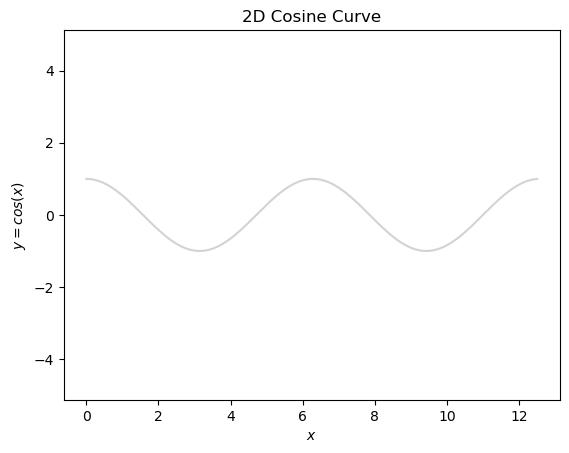

In [5]:
plt.plot( A[:,0], A[:,1], "lightgrey")
plt.title("2D Cosine Curve")
plt.xlabel(r'$x$')
plt.ylabel(r'$y=cos(x)$')
plt.axis("equal")
plt.show()

<img src="p1.png" width="450" style="float: right"/>

**P1** (2 Points). In the coding cell below, write a small program that numerically estimates the `critical points`. To receive full credit, your solution must produce a plot identical to the one provided. 


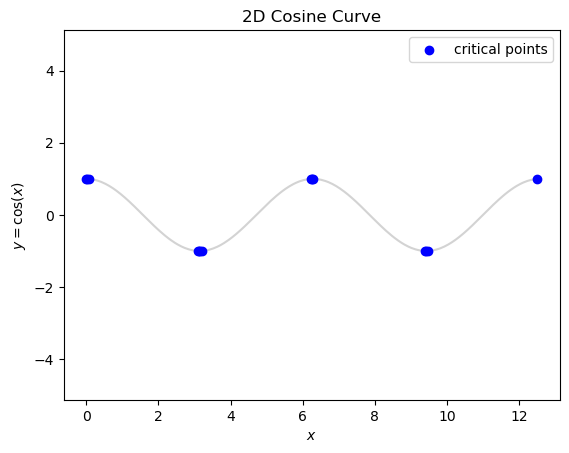

In [6]:
# --------------------------------------
# Add your P1 coding solution below.
# --------------------------------------

# Finding Critical Point

# First Derivative

# Get x and ys 
x = A[:, 0]
y = A[:, 1]

# Make an array for derivatives
dy_dx = np.zeros(len(y))


for i in range(1, len(y) - 1):
    dy_dx[i] = (y[i+1] - y[i-1]) / (x[i+1] - x[i-1])



# Get critical points with a small tolerance 
tol = 5e-2
critical_idx = []
for i in range(len(dy_dx)):
    if abs(dy_dx[i]) < tol:
        critical_idx.append(i)

x_crit = x[critical_idx]
y_crit = y[critical_idx]

# plot
plt.plot(A[:,0], A[:,1], "lightgrey")
plt.scatter(x_crit, y_crit, color="blue", zorder=3, label="critical points")
plt.title("2D Cosine Curve")
plt.xlabel(r"$x$")
plt.ylabel(r"$y=\cos(x)$")
plt.axis("equal")
plt.legend()
plt.show()

            



<img src="p2.png" width="450" style="float: right"/>

**P2** (2 Points). In the coding cell below, write a small program that numerically estimates the `convex points`. To receive full credit, your solution must produce a plot identical to the one provided. 



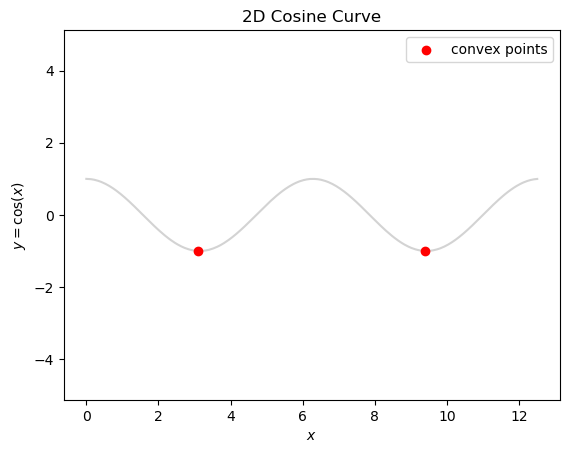

In [7]:
# --------------------------------------
# Add your P2 coding solution below.
# --------------------------------------

x = A[:, 0]
y = A[:, 1]

convex_pt = []

for i in range(1, len(y)-1):
    if y[i] < y[i-1] and y[i] < y[i+1]:
        convex_pt.append(i)

x_convex = x[convex_pt]
y_convex = y[convex_pt]

plt.plot(A[:,0], A[:,1], "lightgrey")
plt.scatter(x_convex, y_convex, color="red", zorder=3, label="convex points")
plt.title("2D Cosine Curve")
plt.xlabel(r"$x$")
plt.ylabel(r"$y=\cos(x)$")
plt.axis("equal") 
plt.legend()      
plt.show()

<img src="p3.png" width="450" style="float: right"/>

**P3** (4 Points). In the coding cell below, write a small program that numerically estimates the **unit** (using the L2 norm) tangent and normal vectors only for the **blue** points. To receive full credit, your solution must create a plot identical to the one provided. <ins>Note</ins>: The color of the tangent line is `magenta`, and the color of the normal line is `green`.

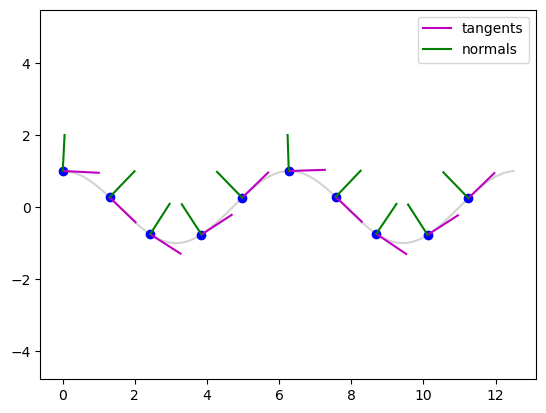

In [8]:
# --------------------------------------
# This code is provided to you.
# Do not modify it.
# --------------------------------------
delta=50
plt.plot( A[:,0], A[:,1], "lightgrey" )
plt.plot( A[::delta, 0], A[::delta,1], "bo" ) # blue points are the every 50th(delta) row 
plt.axis("equal")

# --------------------------------------
# Add your P3 coding solution below.
# --------------------------------------

x = A[:, 0]
y = A[:, 1]

#The unit tangent vector \(\mathbf{T}(t)\) at a point on a curve \(r(t)\) is calculated by 
# dividing the tangent vector (derivative) \(\mathbf{r}^{\prime }(t)\) by its magnitude \(\|\mathbf{r}^{\prime }(t)\|\). 

# derivatives 
# dx

tangent_plotted = False
normal_plotted = False

for i in range(0, len(A), delta):
    dx = x[i+1] - x[i-1]
    dy = y[i+1] - y[i-1]
    
    if i == 0:
        dx = x[i+1] - x[i]
        dy = y[i+1] - y[i]
    magnitude = np.sqrt(dx**2 + dy**2) 

    Tx = dx/magnitude
    Ty = dy/magnitude
        
    Nx = -Ty
    Ny = Tx

    label_tangent = "tangents" if not tangent_plotted else None
    label_normal = "normals" if not normal_plotted else None

    if i == 0:
        Nx = -Ty
        Ny = Tx
          
    plt.plot(
        [x[i], x[i] + Tx],
        [y[i], y[i] + Ty],
        "m-", label=label_tangent
    )
    
    plt.plot(
        [x[i], x[i] + Nx],
        [y[i], y[i] + Ny],
        "g-", label=label_normal
    )
    
    tangent_plotted = True
    normal_plotted = True
    
plt.legend()
plt.show()


****

## Data standardization and normalization.

The dataframe (**df**) shown below defines two features (or columns) labeled **f1** and **f2**, each with $1,000$ samples. Also shown are histogram plots for each feature.

**Tips**:
- This numpy <a href="https://numpy.org/doc/stable/user/absolute_beginners.html">tutorial</a> may be helpful.
- The data visualization notebook (see Canvas schedule, 1/13) may be helpful.
- The data manipulation notebook (see Canvas schedule, 1/13) may be helpful.
- The Mathematics overview slides (see Canvas schedule) may be helpful.
- The Data representation and processing slides (see Canvas schedule) may be helpful.

In [9]:
df = pd.read_csv("G.csv")
df

,f1,f2
0,-2.110000,0.130529
1,1.005415,2.480679
2,1.410057,3.321763
3,6.259839,2.880217
4,5.100076,1.930848
...,...,...
995,2.380652,0.767333
996,-0.757000,1.108744
997,1.668813,2.938973
998,2.400584,1.796796


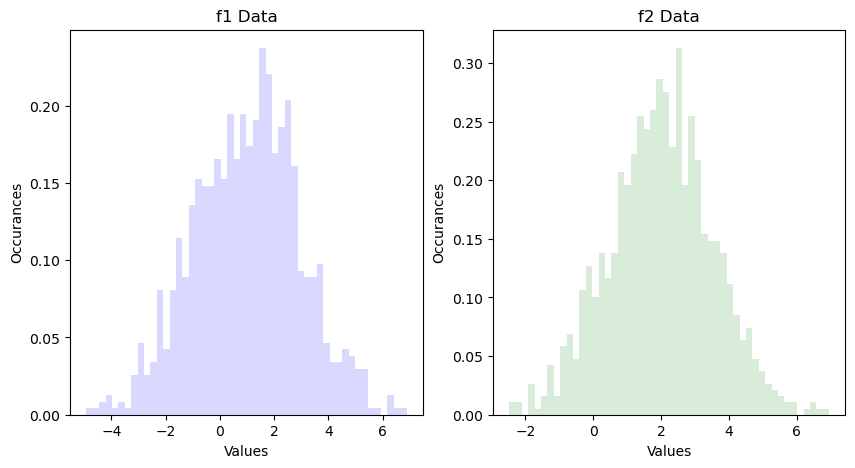

In [10]:
plt.figure( figsize=(10,5) )
plt.subplot(121)
plt.hist( "f1", bins=50, density=True, facecolor="blue", alpha=0.15, data=df )
plt.xlabel( "Values")
plt.ylabel( "Occurances" )
plt.title("f1 Data")
plt.subplot(122)
plt.hist( "f2", bins=50, density=True, facecolor="green", alpha=0.15, data=df )
plt.xlabel( "Values")
plt.ylabel( "Occurances" )
plt.title("f2 Data")
plt.show()

<img src="p4.png" width="450" style="float: right"/>

**P4** (3 Points). In the coding cell below, write a small program that:
- Fit the **f1** values to a normal distribution and overlay them on the histogram plot.
- Standardize the **f1** values using the z-score and display them in a histogram plot.
- Fit the z-score **f1** values to a normal distribution and overlay them on the z-score histogram plot.

To receive full credit, your solution must create a plot identical to the one provided. 

<ins>Note(s)</ins>: 
- The number of histogram bins is $50$.
- The line color for the non-standardized distribution is **blue**.
- The line color for the standardized distribution is **red**.
- The x-axis for both distributions begin at $-10$ and end at $10$ (inclusive).

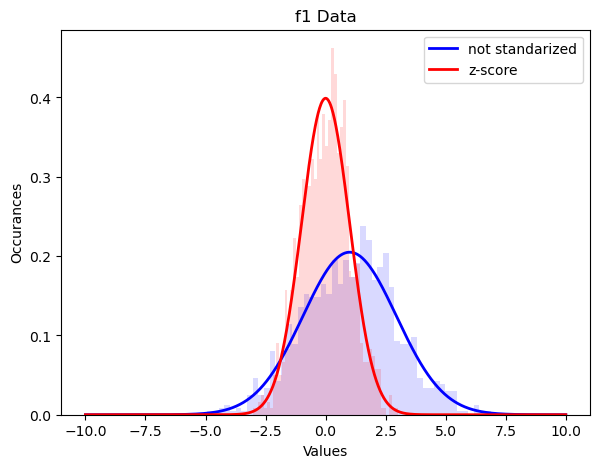

In [17]:
# --------------------------------------
# This code is provided to you.
# Do not modify it.
# --------------------------------------

x = np.linspace(-10,10,1000)

# --------------------------------------
# Add your P4 coding solution below.
# --------------------------------------

f1 = df["f1"]

mu = np.mean(f1)
sigma = np.std(f1)

distr_f1 = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu) / sigma) ** 2
)

plt.figure( figsize=(15,5) )
plt.subplot(121)
plt.hist( "f1", bins=50, density=True, facecolor="blue", alpha=0.15, data=df )
plt.xlabel( "Values")
plt.ylabel( "Occurances" )
plt.title("f1 Data")
plt.plot(x, distr_f1, 'b-', linewidth=2, label='not standarized')


f1_std = (f1 - mu) / sigma

mu_std = np.mean(f1_std)
sigma_std = np.std(f1_std)

distr_z_f1 = (1 / (sigma_std * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu_std) / sigma_std) ** 2
)

plt.hist(f1_std, bins=50, density=True, alpha=0.15, color='red')
plt.plot(x, distr_z_f1, 'r-', linewidth=2, label='z-score')
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.legend()
plt.show()


<img src="p5.png" width="450" style="float: right"/>

**P5** (3 Points). In the coding cell below, write a small program that:
- Fit the **f2** values to a normal distribution and overlay them on the histogram plot.
- Standardize the **f2** values using the z-score and display them in a histogram plot.
- Fit the z-score **f2** values to a normal distribution and overlay them on the z-score histogram plot.

To receive full credit, your solution must create a plot identical to the one provided. 

<ins>Note(s)</ins>: 
- The number of histogram bins is $50$.
- The line color for the non-standardized distribution is **green**.
- The line color for the standardized distribution is **red**.
- The x-axis for both distributions begin at $-10$ and end at $10$ (inclusive).
    

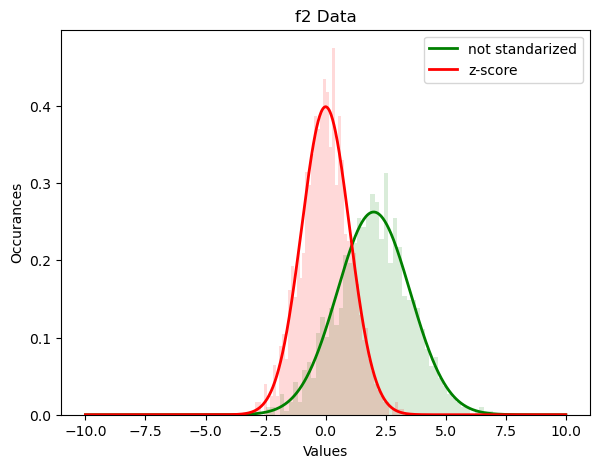

In [19]:
# --------------------------------------
# This code is provided to you.
# Do not modify it.
# --------------------------------------

x = np.linspace(-10,10,1000)

# --------------------------------------
# Add your P5 coding solution below.
# --------------------------------------
f2 = df["f2"]

mu = np.mean(f2)
sigma = np.std(f2)

distr_f2 = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu) / sigma) ** 2
)

plt.figure( figsize=(15,5) )
plt.subplot(121)
plt.hist( "f2", bins=50, density=True, facecolor="green", alpha=0.15, data=df )
plt.xlabel( "Values")
plt.ylabel( "Occurances" )
plt.title("f2 Data")
plt.plot(x, distr_f2, 'g-', linewidth=2, label='not standarized')


f2_std = (f2 - mu) / sigma

mu_std = np.mean(f2_std)
sigma_std = np.std(f2_std)

distr_z_f2 = (1 / (sigma_std * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu_std) / sigma_std) ** 2
)

plt.hist(f2_std, bins=50, density=True, alpha=0.15, color='red')
plt.plot(x, distr_z_f2, 'r-', linewidth=2, label='z-score')
plt.xticks(np.arange(-10, 12.5, 2.5))
plt.legend()
plt.show()



<img src="p6.png" width="450" style="float: right"/>

**P6** (3 Points). In the coding cell below, write a small program that: 
* Numerically compute the $L_p$ norm for $p \in \{0, 1, 2, \infty\}$. $$\|z\|_p = \biggl(\sum_i \lvert x_i\rvert^p\biggr)^\tfrac1{p}$$
* Create the contour plots as referenced (the `fuchsia` colored contour is at level 1).

To receive full credit, your solution must create a plot identical to the one provided. 


Tips:
- Look at the <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html">contourf</a> function.
- Look at the <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html">contour</a> function.
- Look at the <a href="https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html">meshgrid</a> function.


<ins>Note(s)</ins>:
- The plot figure size is $7$ inches in width and $7$ inches in height.
- The plot figure uses a tight layout.
- The default x-axis and y-axis tick values are used.
- The number of contourf levels is $21$.
- The contour color map (cmap attribute) is `coolwarm`.
- The contour color map for level=1 (only) is `fuchsia`.


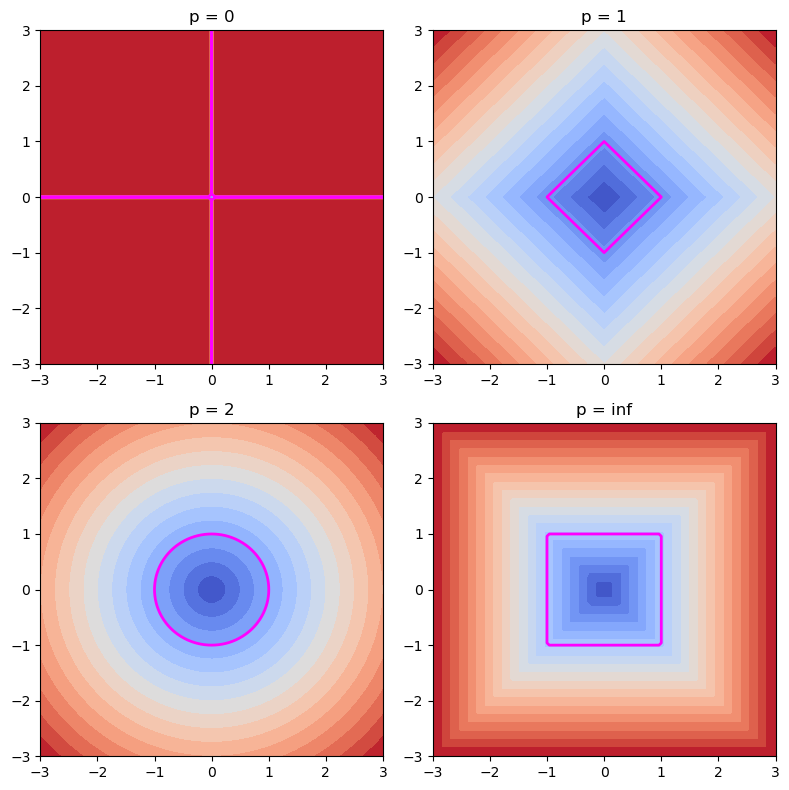

In [259]:
# --------------------------------------
# This code is provided to you.
# Do not modify it.
# --------------------------------------

p_values = [0, 1, 2, np.inf]
x = np.linspace(-3, 3, num=101)
y = np.linspace(-3, 3, num=101)

# --------------------------------------
# Add your P6 coding solution below.
# --------------------------------------



X, Y = np.meshgrid(x, y)

plt.figure(figsize=(7, 7))

for i in range(len(p_values)):
    p = p_values[i]
    
    plt.subplot(2, 2, i + 1)
    
    if p == 0:
        Z = (X != 0).astype(float) + (Y != 0).astype(float)
    elif p == np.inf:
        Z = np.maximum(np.abs(X), np.abs(Y))
    else:
        Z = (np.abs(X)**p + np.abs(Y)**p)**(1/p)
    
    plt.contourf(X, Y, Z, levels=21, cmap='coolwarm')
    plt.contour(X, Y, Z, levels=[1], colors='fuchsia')
    plt.title("p = " + str(p))

plt.tight_layout()
plt.show()







****

## Probability and statistics numerical approximations.

Assume that $X$ is a **discrete random variable** with the following values.

$$
X \in \{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10\}.
$$

This is provided below in an array called `X`. Each outcome $x$ has an associated probability $P(X = x)$. These probabilities are provided below as an array called `P`, where `P[x]` represents the probability that $X = x$. 


**Expectation (Mean)**

The **expectation** (or *expected value*) of a random variable measures its central tendency. It is defined as a weighted average of all possible values of $X$, where the weights are their probabilities:

$$
E[X] = \sum_i x_i \cdot P(X = x_i).
$$

Intuitively, $E[X]$ represents the long-run average value of $X$ if the experiment were repeated many times.

**Variance (Spread)**

The **variance** measures how spread out the values of $X$ are around the expectation. It is defined as

$$
\mathrm{Var}(X) = \sum_i (x_i - E[X])^2 \cdot P(X = x_i).
$$

A larger variance indicates that the values of $X$ tend to be farther from the mean.




**Note**: You must not use `np.mean`, `np.var`, or `np.std`, or similar mean/variance functions from the numpy library.

In [98]:
# Discrete random variable
X = np.array([0,1,2,3,4,5,6,7,8,9])
# Associated probabilities
P = np.array([0.2260153861463917, 0.12900657162498763, 0.08500627955243865, 
              0.07098961058796043, 0.21995903817219636, 0.005579853293992449, 
              0.008228012415692425, 0.020628132017486107, 0.03011219526641962, 
              0.20447492092243466])

print( "X: shape={}, X={}".format( X.shape, X ) )
print( "P. shape={}, P={}".format( P.shape, P ) )

X: shape=(10,), X=[0 1 2 3 4 5 6 7 8 9]
P. shape=(10,), P=[0.22601539 0.12900657 0.08500628 0.07098961 0.21995904 0.00557985
 0.00822801 0.02062813 0.0301122  0.20447492]


**P7** (2 points). In the coding cell below, write a small program that numerically computes and then prints the expectation $E[X]$ and variance $\text{Var}[X]$.

In [99]:
# --------------------------------------
# Add your P7 coding solution below.
# --------------------------------------











**P8** (2 points). In the coding cell below, write a small program that generates $1,000$ random samples from $X$ according to the given probability distribution, and then numerically compute and print the **empirical mean** and **empirical variance** using the randomly generated samples (<ins>Note</ins>: the empirical variance is a biased estimate).

To compute the empirical values, you **cannot** use `np.mean`, `np.var`, or `np.std`, or any other similar mean/variance functions in the numpy library.

**Hint**: Look at the <a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html">choice</a> function to generate random samples according to a probability distribution.

In [100]:
# --------------------------------------
# Add your P8 coding solution below.
# --------------------------------------











<img src="p9.png" width="600" style="float: right"/>

**P9** (4 points). In the coding cell below, create the probability and empirical distribution plots (using numpy <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html">bar</a>).
* For the probability plot, the X-axis is the outcomes of $X$, and each bar shows the corresponding probability.
* For the empirical plot, the X-axis is the outcomes of $X$, and each bar shows the corresponding count.

To receive full credit, your plot must be identical to the one provided.

<ins>Note(s)</ins>:
- The plot figure size is $12$ inches in width and $4$ inches in height.
- The plot figure uses a tight layout.
- The default x-axis and y-axis tick values are used.
- The color of the bars in the probability plot is `blue`.
- The color of the bars in the empirical plot is `orange`.

In [101]:
# --------------------------------------
# Add your P9 coding solution below.
# --------------------------------------










### Extra Credit

Assume we have two continuous random variables $X$ and $Y$ supported on the unit square $[0,1] \times [0,1]$, with joint probability density function

$$
f_{X,Y}(x,y) = \frac{12}{19}\,(5xy + y^2), \qquad 0 \le x \le 1,\; 0 \le y \le 1.
$$

The continuous **marginal densities** of $X$ and $Y$, denoted as $f_X(x)$ and $f_Y(y)$, are obtained by integrating the joint distribution on the other variable:
$$
f_X(x_i) = \int_0^1 f_{X,Y}(x_i, y) \: dy
$$
$$\quad f_Y(y_i) = \int_0^1 f_{X,Y}(x, y_i) \: dx
$$

The continuous integral $f_X(x)$ can be numerically approximated using the **midpoint** rule as follows:

$$
\int_0^1 f_{X,Y}(x_i, y) dy \approx \sum_{j=0}^{N-1} f_{X,Y}(x_i, y_j^*) \Delta y
$$

where $y_j^*$ is the midpoint of the $j$-th interval, and $\Delta y$ is the grid spacing along the $y$-axis, which is $y_j^* - y_{j-1}^*$.

Likewise, $f_Y(y)$ can be numerically approximated as follows:

$$
\int_0^1 f_{X,Y}(x, y_i) dx \approx \sum_{j=0}^{N-1} f_{X,Y}(x_i^*, y_j) \Delta x
$$

where $x_j^*$ is the midpoint of the $j$-th interval, and $\Delta x$ is the grid spacing along the $x$-axis, which is $x_j^* - x_{j-1}^*$.

<ins>Note(s)</ins>:
* $N$ is 100 (i.e., $N$ equally spaced points in $[0,1]$).
* $x$-coordinate and $y$-coordinate midpoint values (`x_mid` and `y_mid`) are provided in the coding cell below.

In [102]:
n_points = 100
x = np.linspace(0, 1, n_points, endpoint=True )
y = np.linspace(0, 1, n_points)

x_mid = (x[:-1] + x[1:]) / 2
y_mid = (y[:-1] + y[1:]) / 2

print( "x: shape={}".format( x.shape ) )
print( "y: shape={}".format( y.shape ) )

x: shape=(100,)
y: shape=(100,)


<img src="ec1.png" width="600" style="float: right"/>


**E1** (2 points). In the coding cell below, numerically compute the marginal densities and generate the plots:
* The marginal density of X is $f_X(x)$.
* The marginal density of Y is $f_Y(y)$.

To receive full credit, your plot must be identical to the one provided.

<ins>Note(s)</ins>:
- The plot figure size is $10$ inches in width and $5$ inches in height.
- The plot figure uses a tight layout.
- The default x-axis and y-axis tick values are used.
- The color of the $f_X(x)$ line plot is `blue`.
- The color of the $f_Y(y)$ line plot is `red`.

In [103]:
# --------------------------------------
# Add your E1 coding solution below.
# --------------------------------------















